## Section 0 — Repo Setup

Clones the repo and checks out the working branch.  
Safe to re-run — skips clone if the directory already exists.

In [44]:
%%bash
set -euo pipefail

REPO_URL="https://github.com/Avi161/temporal-awareness.git"
REPO_DIR="temporal-awareness"
BRANCH="test/steering"

if [ ! -d "$REPO_DIR/.git" ]; then
  git clone "$REPO_URL" "$REPO_DIR"
fi

cd "$REPO_DIR"
git fetch --all --prune
git checkout "$BRANCH"
if git ls-remote --exit-code --heads origin "$BRANCH" >/dev/null 2>&1; then
  git pull --ff-only origin "$BRANCH"
fi

echo "Branch: $(git branch --show-current)"
git log -1 --oneline

Fetching origin
Your branch is behind 'origin/test/steering' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
Updating f5a7157..6cabf05
Fast-forward
 NEXT_STEPS.md                            | 216 -------
 PLAN.MD                                  | 156 +++++
 notebooks/08_steering_from_scratch.ipynb | 961 +++++++++++++++++++++++++++++++
 scripts/week1/activation_extractor.py    |  33 +-
 4 files changed, 1144 insertions(+), 222 deletions(-)
 delete mode 100644 NEXT_STEPS.md
 create mode 100644 PLAN.MD
 create mode 100644 notebooks/08_steering_from_scratch.ipynb
Branch: test/steering
6cabf05 update token position bug


From https://github.com/Avi161/temporal-awareness
   f5a7157..6cabf05  test/steering -> origin/test/steering
Already on 'test/steering'
From https://github.com/Avi161/temporal-awareness
 * branch            test/steering -> FETCH_HEAD


## Section 1 — Install Dependencies

Installs the repo as an editable package so all `src.*` imports work.  
**After this cell finishes: Runtime → Restart runtime, then continue from Section 2.**

In [45]:
%%bash
set -euo pipefail
cd /content/temporal-awareness

python -m pip install --upgrade --quiet pip setuptools wheel
python -m pip install --quiet -e '.[dev]'
python -m pip install --quiet ipykernel

echo "Done. Restart the runtime now."

Done. Restart the runtime now.


## Section 2 — Imports & Configuration

All Python imports in one place.  
Make sure the runtime has been restarted after Section 1.

In [46]:
import json
import sys
from pathlib import Path

import torch
from transformer_lens import HookedTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import login
from getpass import getpass

# ── Make sure we're in the repo root ──────────────────────────────────────
REPO_ROOT = Path('/content/temporal-awareness')
if REPO_ROOT.exists() and Path.cwd() != REPO_ROOT:
    %cd /content/temporal-awareness

# Add repo to sys.path (belt-and-suspenders for editable install)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.inference.model_runner import ModelRunner
from src.inference.backends import ModelBackend
from src.inference.backends.transformerlens import TransformerLensBackend

# ── Constants ─────────────────────────────────────────────────────────────
MODEL_NAME            = "Qwen/Qwen3-4B-Instruct-2507"
DATASET_PATH          = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json")
IMPLICIT_DATASET_PATH = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json")
OUT_DIR               = REPO_ROOT / 'out' / 'steering_from_scratch'

print("Imports OK.")
print(f"  torch  : {torch.__version__}")
print(f"  device : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"  model  : {MODEL_NAME}")

Imports OK.
  torch  : 2.10.0+cu128
  device : cuda
  model  : Qwen/Qwen3-4B-Instruct-2507


## Section 3 — Auth & Google Drive

- Logs in to Hugging Face (needed to download the gated Qwen model).
- Mounts Google Drive and symlinks `out/` so all experiment artifacts persist across sessions.

In [47]:
# ── Hugging Face login ─────────────────────────────────────────────────────
hf_token = getpass("Hugging Face token (hidden): ")
login(token=hf_token)
print("HF login OK.")

# ── Google Drive ───────────────────────────────────────────────────────────
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')

    DRIVE_OUT  = Path('/content/drive/MyDrive/temporal-awareness-out')
    DRIVE_OUT.mkdir(parents=True, exist_ok=True)

    LOCAL_OUT = REPO_ROOT / 'out'
    if LOCAL_OUT.is_symlink():
        LOCAL_OUT.unlink()
    elif LOCAL_OUT.exists():
        import shutil
        backup = REPO_ROOT / 'out_local_backup'
        if backup.exists():
            shutil.rmtree(backup)
        LOCAL_OUT.rename(backup)

    LOCAL_OUT.symlink_to(DRIVE_OUT, target_is_directory=True)
    print(f"Drive mounted.  out/ → {DRIVE_OUT}")

except ImportError:
    print("Not in Colab — skipped Drive mount. out/ stays local.")

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts → {OUT_DIR}")

HF login OK.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.  out/ → /content/drive/MyDrive/temporal-awareness-out
Artifacts → /content/temporal-awareness/out/steering_from_scratch


## Section 4 — Datasets

- **Explicit** (`temporal_scope_explicit_expanded_500.json`) — 500 A/B pairs with explicit short-term vs long-term framing.
- **Implicit** (`temporal_scope_implicit_expanded_300.json`) — 300 A/B pairs where the temporal scope is implied.

In [48]:
for p in (DATASET_PATH, IMPLICIT_DATASET_PATH):
    if not p.exists():
        raise FileNotFoundError(f"Dataset not found: {p}")

with open(DATASET_PATH)  as f: explicit_ds = json.load(f)
with open(IMPLICIT_DATASET_PATH) as f: implicit_ds = json.load(f)

explicit_pairs = explicit_ds.get('pairs', [])
implicit_pairs = implicit_ds.get('pairs', [])

print(f"Explicit pairs : {len(explicit_pairs)}")
print(f"Implicit pairs : {len(implicit_pairs)}")
print("\nExplicit sample:", explicit_pairs[0])
print("\nImplicit sample:", implicit_pairs[0])

Explicit pairs : 500
Implicit pairs : 300

Explicit sample: {'id': 1, 'category': 'planning', 'question': 'When developing a roadmap for this initiative, consider:', 'immediate': ' (A) What we can deliver in the next 30 days', 'long_term': ' (B) What position we want in 10 years'}

Implicit sample: {'id': 1, 'question': 'When the system fails, the first priority becomes', 'immediate': ' (A) containing the spreading damage before it escalates', 'long_term': ' (B) redesigning the architecture to prevent recurrence', 'category': 'crisis_vs_foundation'}


## Section 5 — Model Loading

`Qwen/Qwen3-4B-Instruct-2507` is not in TransformerLens's model registry, but `Qwen/Qwen3-4B`
(same architecture, different weights) is.  
We monkey-patch `ModelRunner._init_transformerlens` with an arch-mapping table so the rest of
the notebook can use the identical one-liner that `06_probing_and_steering.ipynb` uses for Llama:

```python
runner = ModelRunner(MODEL_NAME, backend=ModelBackend.TRANSFORMERLENS, dtype=torch.float16)
```

In [49]:
# ── Arch-mapping table (extend if you switch models later) ────────────────
TL_ARCH_MAP = {
    "Qwen/Qwen3-4B-Instruct-2507": "Qwen/Qwen3-4B",
}

def _patched_init_transformerlens(self) -> None:
    arch_ref   = TL_ARCH_MAP.get(self.model_name, self.model_name)
    in_registry = (arch_ref == self.model_name)

    print(f"Loading {self.model_name} on {self.device} (TransformerLens)...")

    if in_registry:
        self._model = HookedTransformer.from_pretrained_no_processing(
            self.model_name, device=self.device, dtype=self.dtype
        )
    else:
        print(f"  arch ref → {arch_ref}")
        hf_model  = AutoModelForCausalLM.from_pretrained(
            self.model_name, torch_dtype=self.dtype, device_map="cpu"
        )
        tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self._model = HookedTransformer.from_pretrained(
            arch_ref,
            hf_model=hf_model,
            tokenizer=tokenizer,
            dtype=self.dtype,
            move_to_device=True,
            fold_ln=False,
            center_writing_weights=False,
            center_unembed=False,
        )
        del hf_model

    self._model.eval()
    self._backend = TransformerLensBackend(self)

ModelRunner._init_transformerlens = _patched_init_transformerlens
print("Patch applied.")

Patch applied.


In [50]:
runner = ModelRunner(
    MODEL_NAME,
    backend=ModelBackend.TRANSFORMERLENS,
    dtype=torch.float16,
)

N_LAYERS = runner.n_layers
D_MODEL  = runner.d_model

print(f"n_layers = {N_LAYERS}")
print(f"d_model  = {D_MODEL}")

Loading Qwen/Qwen3-4B-Instruct-2507 on cuda (TransformerLens)...
  arch ref → Qwen/Qwen3-4B


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer
Model loaded: ModelBackend.TRANSFORMERLENS Qwen/Qwen3-4B-Instruct-2507 (chat=True)
  n_layers=36, d_model=2560

n_layers = 36
d_model  = 2560


In [51]:
# ── Forward-pass sanity check ──────────────────────────────────────────────
logits, cache = runner.run_with_cache(
    "When planning under uncertainty, prioritize:",
    names_filter=lambda n: "hook_resid_post" in n,
)

assert len(cache) == N_LAYERS, f"Expected {N_LAYERS} cached tensors, got {len(cache)}"
act_shape = tuple(list(cache.values())[0].shape)
assert act_shape[-1] == D_MODEL, f"d_model mismatch: {act_shape}"

print("Sanity check passed.")
print(f"  logits : {tuple(logits.shape)}")
print(f"  cache  : {len(cache)} tensors, each {act_shape}")

Sanity check passed.
  logits : (1, 15, 151936)
  cache  : 36 tensors, each (1, 15, 2560)


## Section 6 — Probing

**Goal**: find the layer where the model linearly encodes the temporal concept
(short-term vs long-term) most clearly.

**Protocol** (identical to `06_probing_and_steering.ipynb`):

1. Build prompts by concatenating `question + choice` for every pair.
2. Extract last-token residual-stream activations at every layer — shape `[n, n_layers, d_model]`.
3. Train one `LogisticRegression(C=0.1)` probe per layer on the **implicit** dataset (80/20 split).
4. Plot test accuracy per layer → identify the peak layer.
5. Zero-shot evaluate those same probes on the **explicit** dataset to test cross-dataset generalisation.

The **implicit** dataset has no surface time-words, so the probe direction captures
semantic temporal reasoning rather than keyword patterns.

In [52]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scripts.week1.activation_extractor import extract_activations_for_prompts

PROBE_OUT_DIR = OUT_DIR / "probing"
PROBE_OUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE  = 42

print(f"Probe artifacts → {PROBE_OUT_DIR}")

Probe artifacts → /content/temporal-awareness/out/steering_from_scratch/probing


In [53]:
# ── Build prompts (question + choice concatenation, same as notebook 06) ──
impl_immediate = [p["question"] + p["immediate"] for p in implicit_pairs]
impl_long_term = [p["question"] + p["long_term"]  for p in implicit_pairs]
expl_immediate = [p["question"] + p["immediate"] for p in explicit_pairs]
expl_long_term = [p["question"] + p["long_term"]  for p in explicit_pairs]

N_IMPL = len(implicit_pairs)
N_EXPL = len(explicit_pairs)

print(f"Implicit : {N_IMPL} pairs  ({N_IMPL*2} prompts)")
print(f"Explicit : {N_EXPL} pairs  ({N_EXPL*2} prompts)")
print(f"\nImplicit immediate[0]: {impl_immediate[1]!r}")
print(f"Implicit long-term[0]: {impl_long_term[1]!r}")

Implicit : 300 pairs  (600 prompts)
Explicit : 500 pairs  (1000 prompts)

Implicit immediate[0]: 'The hospital administrator directs resources toward (B) stabilizing patients in critical condition'
Implicit long-term[0]: 'The hospital administrator directs resources toward (A) training staff and upgrading medical equipment'


In [54]:
# ── Token-position sanity check ───────────────────────────────────────────
# The Qwen chat template wraps every prompt as:
#
#   <|im_start|>system\n...<|im_end|>\n
#   <|im_start|>user\n<choice text><|im_end|>\n
#   <|im_start|>assistant\n
#
# So position -1 is the trailing '\n' of the assistant turn, NOT the choice text.
# extract_activations_for_prompts (scripts/week1/activation_extractor.py) now
# finds the last <|im_end|> in the sequence and reads position (last_im_end - 1),
# which is the final token of the choice text.
#
# Run this cell to confirm the target index looks correct for the first prompt.

_raw      = impl_immediate[0]
_fmt      = runner.apply_chat_template(_raw)
_ids      = runner.encode(_fmt)[0].tolist()
_tokens   = runner._model.tokenizer.convert_ids_to_tokens(_ids)
_im_end   = runner._model.tokenizer.convert_tokens_to_ids("<|im_end|>")
_last_pos = max(i for i, t in enumerate(_ids) if t == _im_end)
_target   = _last_pos - 1

print(f"Sequence length : {len(_ids)} tokens")
print(f"Last <|im_end|> : position {_last_pos}  → token {repr(_tokens[_last_pos])}")
print(f"Target position : {_target}              → token {repr(_tokens[_target])}")
print()
print("Context around target:")
for i in range(max(0, _target - 3), min(len(_ids), _target + 4)):
    marker = " ◄ TARGET" if i == _target else ""
    print(f"  {i:>4}  {_ids[i]:>10}  {repr(_tokens[i])}{marker}")

Sequence length : 28 tokens
Last <|im_end|> : position 23  → token '<|im_end|>'
Target position : 22              → token 'ates'

Context around target:
    19        1573  'Ġbefore'
    20         432  'Ġit'
    21       26435  'Ġescal'
    22         973  'ates' ◄ TARGET
    23      151645  '<|im_end|>'
    24         198  'Ċ'
    25      151644  '<|im_start|>'


In [55]:
# ── Extract implicit activations ──────────────────────────────────────────
# Shape: [n_prompts, n_layers, d_model]
acts_impl_imm = extract_activations_for_prompts(runner, impl_immediate, desc="Implicit  immediate")
acts_impl_lt  = extract_activations_for_prompts(runner, impl_long_term,  desc="Implicit  long-term")

assert torch.isfinite(acts_impl_imm).all() and torch.isfinite(acts_impl_lt).all(), \
    "Non-finite values in implicit activations!"

print(f"Implicit immediate : {tuple(acts_impl_imm.shape)}")
print(f"Implicit long-term : {tuple(acts_impl_lt.shape)}")
print("Finite check: OK")

Implicit  long-term: 100%|██████████| 300/300 [00:37<00:00,  7.98it/s]


Implicit immediate : (300, 36, 2560)
Implicit long-term : (300, 36, 2560)
Finite check: OK


In [56]:
# ── Extract explicit activations ──────────────────────────────────────────
acts_expl_imm = extract_activations_for_prompts(runner, expl_immediate, desc="Explicit  immediate")
acts_expl_lt  = extract_activations_for_prompts(runner, expl_long_term,  desc="Explicit  long-term")

assert torch.isfinite(acts_expl_imm).all() and torch.isfinite(acts_expl_lt).all(), \
    "Non-finite values in explicit activations!"

print(f"Explicit immediate : {tuple(acts_expl_imm.shape)}")
print(f"Explicit long-term : {tuple(acts_expl_lt.shape)}")
print("Finite check: OK")

Explicit  long-term: 100%|██████████| 500/500 [01:02<00:00,  8.02it/s]


Explicit immediate : (500, 36, 2560)
Explicit long-term : (500, 36, 2560)
Finite check: OK


In [57]:
# ── Train one LogisticRegression probe per layer on implicit data (pair-aware split) ──────────
# Rows 0..N_IMPL-1 = immediate activations, N_IMPL..2*N_IMPL-1 = long_term activations.
X_impl = torch.cat([acts_impl_imm, acts_impl_lt], dim=0).float().numpy()
# Shape: [N_IMPL*2, N_LAYERS, D_MODEL]

# Split on pair indices so both sides of the same question always land in the same
# fold — prevents cross-contamination between train and test sets.
pair_idx = np.arange(N_IMPL)
train_idx, test_idx = train_test_split(
    pair_idx, test_size=0.2, random_state=RANDOM_STATE,
)

layer_results = []

for layer in tqdm(range(N_LAYERS), desc="Training probes"):
    X_layer = X_impl[:, layer, :]              # [N_IMPL*2, D_MODEL]

    # immediate rows: train_idx / test_idx
    # long_term rows: train_idx + N_IMPL / test_idx + N_IMPL
    X_train = np.concatenate([X_layer[train_idx], X_layer[train_idx + N_IMPL]], axis=0)
    X_test  = np.concatenate([X_layer[test_idx],  X_layer[test_idx  + N_IMPL]], axis=0)
    y_train = np.array([0] * len(train_idx) + [1] * len(train_idx))
    y_test  = np.array([0] * len(test_idx)  + [1] * len(test_idx))

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    with open(PROBE_OUT_DIR / f"scaler_layer_{layer:02d}.pkl", "wb") as fh:
        pickle.dump(scaler, fh)

    probe = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)
    probe.fit(X_train, y_train)
    test_acc = probe.score(X_test, y_test)

    with open(PROBE_OUT_DIR / f"probe_layer_{layer:02d}.pkl", "wb") as fh:
        pickle.dump(probe, fh)

    layer_results.append({
        "layer":         layer,
        "test_accuracy": test_acc,
        "n_train":       len(y_train),
        "n_test":        len(y_test),
    })

df_probes = pd.DataFrame(layer_results)
df_probes.to_csv(PROBE_OUT_DIR / "probe_accuracies.csv", index=False)
print(df_probes.to_string(index=False))

Training probes: 100%|██████████| 36/36 [01:23<00:00,  2.31s/it]

 layer  test_accuracy  n_train  n_test
     0       0.866667      480     120
     1       0.800000      480     120
     2       0.841667      480     120
     3       0.758333      480     120
     4       0.791667      480     120
     5       0.783333      480     120
     6       0.766667      480     120
     7       0.791667      480     120
     8       0.816667      480     120
     9       0.783333      480     120
    10       0.833333      480     120
    11       0.841667      480     120
    12       0.833333      480     120
    13       0.850000      480     120
    14       0.916667      480     120
    15       0.891667      480     120
    16       0.891667      480     120
    17       0.900000      480     120
    18       0.908333      480     120
    19       0.916667      480     120
    20       0.925000      480     120
    21       0.933333      480     120
    22       0.933333      480     120
    23       0.925000      480     120
    24       0.908333    

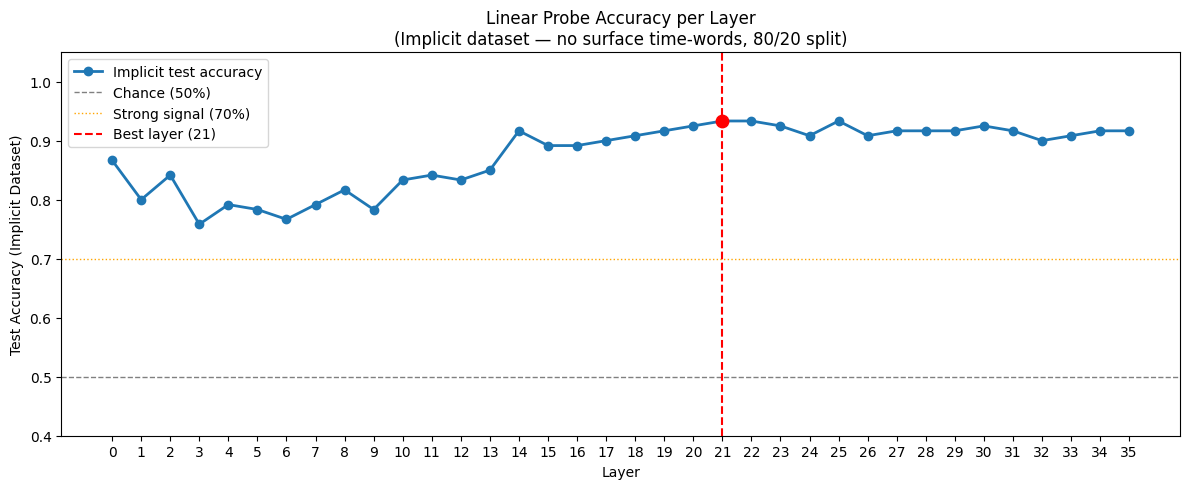


Best layer : 21  |  Test accuracy : 0.933

Top 5 layers:
 layer  test_accuracy  n_train  n_test
    21       0.933333      480     120
    22       0.933333      480     120
    25       0.933333      480     120
    20       0.925000      480     120
    23       0.925000      480     120


In [58]:
# ── Plot implicit test accuracy per layer ─────────────────────────────────
best_layer = int(df_probes.loc[df_probes["test_accuracy"].idxmax(), "layer"])
best_acc   = df_probes.loc[df_probes["test_accuracy"].idxmax(), "test_accuracy"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_probes["layer"], df_probes["test_accuracy"],
        marker="o", linewidth=2, color="tab:blue", label="Implicit test accuracy")
ax.axhline(0.5, color="gray",   linestyle="--", linewidth=1, label="Chance (50%)")
ax.axhline(0.7, color="orange", linestyle=":",  linewidth=1, label="Strong signal (70%)")
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5,
           label=f"Best layer ({best_layer})")
ax.scatter([best_layer], [best_acc], color="red", zorder=5, s=80)

ax.set_xlabel("Layer")
ax.set_ylabel("Test Accuracy (Implicit Dataset)")
ax.set_title("Linear Probe Accuracy per Layer\n(Implicit dataset — no surface time-words, 80/20 split)")
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(PROBE_OUT_DIR / "probe_accuracy_per_layer.png", dpi=150)
plt.show()

print(f"\nBest layer : {best_layer}  |  Test accuracy : {best_acc:.3f}")
print("\nTop 5 layers:")
print(df_probes.nlargest(5, "test_accuracy").to_string(index=False))

In [59]:
# ── Cross-dataset evaluation: apply implicit probes to explicit data ───────
X_expl = torch.cat([acts_expl_imm, acts_expl_lt], dim=0).float().numpy()
y_expl = np.array([0] * N_EXPL + [1] * N_EXPL)

cross_accs = []
for layer in range(N_LAYERS):
    with open(PROBE_OUT_DIR / f"scaler_layer_{layer:02d}.pkl", "rb") as fh:
        scaler = pickle.load(fh)
    with open(PROBE_OUT_DIR / f"probe_layer_{layer:02d}.pkl", "rb") as fh:
        probe = pickle.load(fh)
    X_layer_expl = scaler.transform(X_expl[:, layer, :])
    cross_accs.append(probe.score(X_layer_expl, y_expl))

df_probes["cross_dataset_accuracy"] = cross_accs
df_probes.to_csv(PROBE_OUT_DIR / "probe_accuracies.csv", index=False)
print("Cross-dataset evaluation complete.")

Cross-dataset evaluation complete.


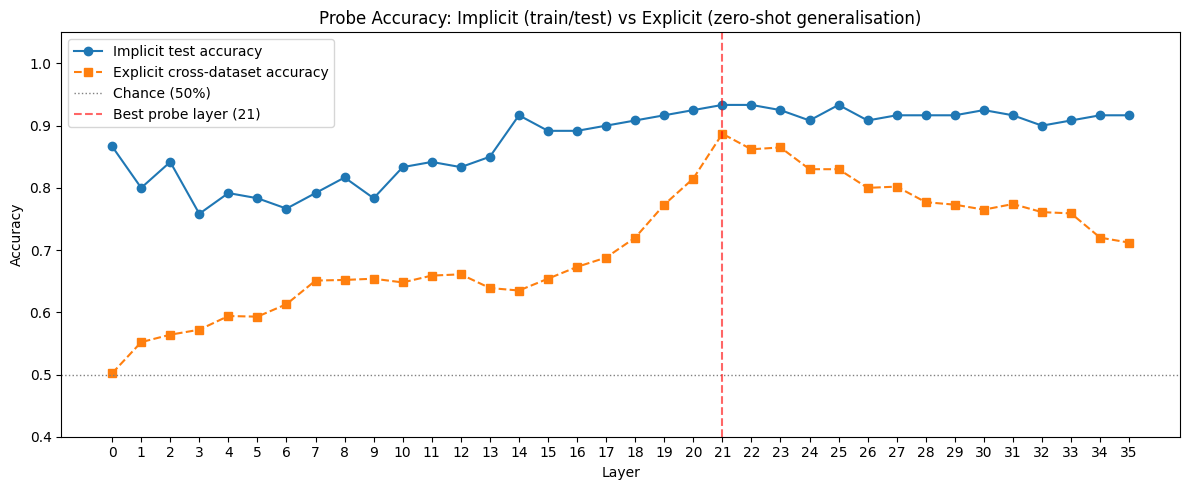


At best probe layer (21):
  Implicit test accuracy:          0.933
  Explicit cross-dataset accuracy: 0.887
  Generalisation gap:              0.046


In [60]:
# ── Plot: implicit test accuracy vs explicit cross-dataset accuracy ────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_probes["layer"], df_probes["test_accuracy"],
        marker="o", label="Implicit test accuracy", color="tab:blue")
ax.plot(df_probes["layer"], df_probes["cross_dataset_accuracy"],
        marker="s", label="Explicit cross-dataset accuracy",
        color="tab:orange", linestyle="--")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Chance (50%)")
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5, alpha=0.6,
           label=f"Best probe layer ({best_layer})")

ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title("Probe Accuracy: Implicit (train/test) vs Explicit (zero-shot generalisation)")
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(PROBE_OUT_DIR / "probe_generalization.png", dpi=150)
plt.show()

print(f"\nAt best probe layer ({best_layer}):")
print(f"  Implicit test accuracy:          {df_probes.loc[best_layer, 'test_accuracy']:.3f}")
print(f"  Explicit cross-dataset accuracy: {df_probes.loc[best_layer, 'cross_dataset_accuracy']:.3f}")
gap = (df_probes.loc[best_layer, "test_accuracy"]
       - df_probes.loc[best_layer, "cross_dataset_accuracy"])
print(f"  Generalisation gap:              {gap:.3f}")